### This notebook illustrates neuronal group mean responses of hippocampal neurons in <br>Dentate gyrus, CA3, and CA1 during dentate spikes and sharp-wave ripples, during non-rem sleep
The code can reproduce the following figure panels: Figure 1 (f,g) and Figure 2 (e,f,g)
McHugh et al. Neuron 112(22): 1-14. https://doi.org/10.1016/j.neuron.2024.08.022

In [1]:
####### Import libraries ##################################################
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
###########################################################################
src_path = Path().resolve().parent / "src"
sys.path.insert(0, str(src_path))

from data_io import data_loader
from plotting import plot_group_mean_psth, generate_heatmaps, figure_chooser 
from analysis import generate_nan_free_z_score, get_max_rate_dict
import dabest_helper as dbh
############################################################################

Pre-compiling numba functions for DABEST...


Compiling numba functions: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 26.92it/s]

Numba compilation complete!


#### Load summary data 

In [2]:
###################################################################################################################
BASE_DIR = Path.cwd().parent
path_to_data = 'data/group_ifr/'
###################################################################################################################
ctype_list = ['pdg','p3','p1'] # these labels refer to principal cells (putative glutamatergic neurons) in DG, CA3, and CA1
###################################################################################################################
all_summary_data = data_loader(BASE_DIR,path_to_data,ctype_list)
###################################################################################################################

#### Plot the group mean averages for each neuron subtype (DG, CA3, CA1) for dentate spikes (DS) and sharp-wave ripples (SWR)
To reproduce Figure 1f, use: figure_panel = 1 <br>
To reproduce Figure 2e, use figure_panel = 2

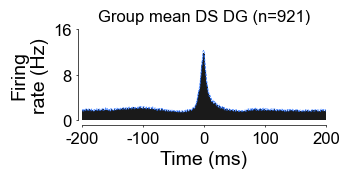

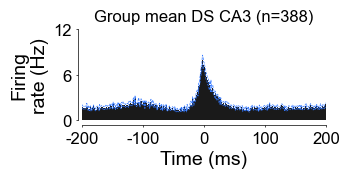

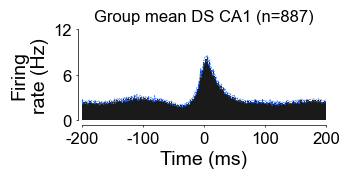

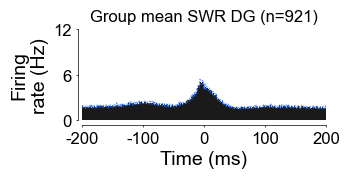

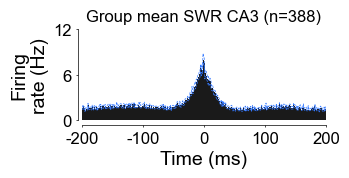

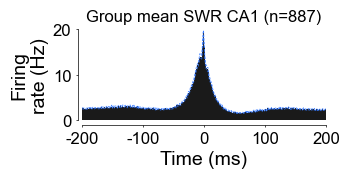

In [3]:
###############################################################################################################
figure_panel = 1
event_type_list = figure_chooser(figure_panel)

for event_indx,event_type in enumerate(event_type_list):
    for cindx,ctype in enumerate(ctype_list):
        fig,ax = plot_group_mean_psth(all_summary_data,event_type,ctype,size_scale=2,fwd=4,fht=1.5,err_bars=True,savgol=False)
        plt.show()
###############################################################################################################################

#### Plot z-scored heatmaps (one neuron per row) for each neuron subtype (DG, CA3, CA1) <br>for dentate spikes (DS) and sharp-wave ripples (SWR)
To reproduce Figure 1g, use: figure_panel = 1 <br>
To reproduce Figure 2f, use figure_panel = 2

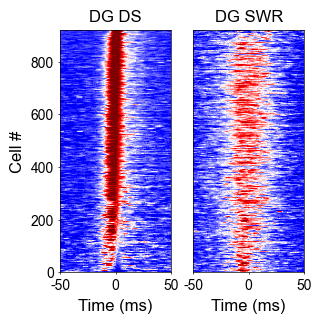

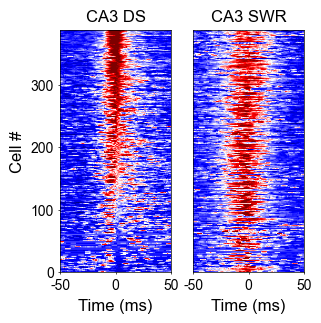

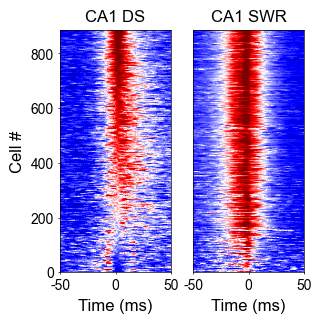

In [4]:
##############################################################################
figure_panel = 1
event_type_list = figure_chooser(figure_panel)
#############################################################################
zscore_dat = generate_nan_free_z_score(all_summary_data,
                                       okey_list=ctype_list,
                                       ikey_list=event_type_list,
                                       smpts=5)

for cindx,ctype in enumerate(ctype_list):
    fig,ax = generate_heatmaps(zscore_dat,
                               ctype,
                               event_type_list,
                               size_scale=2,
                               sort_event=event_type_list[0],
                               cmap='seismic')
##############################################################################

#### Generate group mean data each neuron subtype (DG, CA3, CA1)
for dentate spikes (DS, and subtypes split into DS1 and DS2) and sharp-wave ripples (SWR)<br>during baseline (mean rate during 200ms before each event) <br>...versus during the peak of each event (mean rate during +/- 2 ms either side of local field potential event peak)

In [9]:
###### generate data in dictionary ####################################################################
idata = get_max_rate_dict(all_summary_data,ctype_list)

#### determine columns and conditions to create pandas dataframe from data dictionary #################
outerkey = ['baseline','ds','ds1','ds2','swr']
innerkey = ctype_list
col_head = ['id','Event_Type','Cell_Type','Data','Cell_Event']
col_groups = {
              'pdg':'pdg',
              'p3':'p3',
              'p1':'p1',
             }
#### specify the contrasts for plotting and analyses, each row is a within-samples comparison #######
df_idx = [
            ['pdg_baseline','pdg_ds','pdg_ds1','pdg_ds2','pdg_swr'],
            ['p3_baseline', 'p3_ds','p3_ds1','p3_ds2','p3_swr'],
            ['p1_baseline', 'p1_ds','p1_ds1','p1_ds2','p1_swr']
         ]
#### create a DABEST analysis object, specify that analyses are within-samples (paired='baseline') ####
analysis_of_long_df = dbh.generate_dabest_analysis(idata,
                                                   outerkey,
                                                   innerkey,
                                                   col_head,
                                                   col_groups,
                                                   df_idx,
                                                   paired='baseline',
                                                   x='Cell_Event',
                                                   y='Data')
####################################################################################################

/Dupret_Lab/analysis/smchugh_analysis/SF_analysis/Data_sharing/neuron_2024_repro/src/analysis.py:28: RuntimeWarning: Mean of empty slice
  tempdict[ctype] = np.nanmean(tempdat[xrange[0]:xrange[1]],axis=0)


#### Now generate the estimation plot using DABEST to reproduce Figure 2g
... this might take several minutes

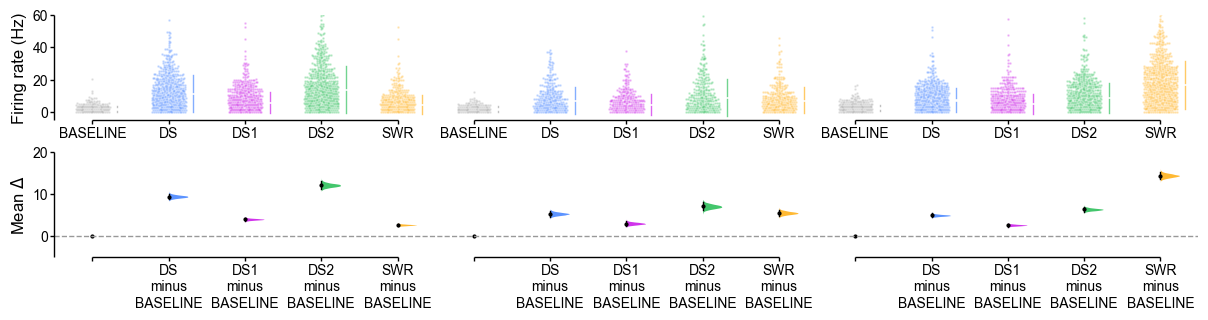

In [10]:
####################################################################################################################
fig,swarm_ax,contrast_ax = dbh.plot_dabest_swarm_contrast(analysis_of_long_df,
                                                           df_idx,
                                                           show_pairs=False,
                                                           diff_type='mean',
                                                           swlab='Firing rate (Hz)',
                                                           size_scale=2,
                                                           fwd=1.25,
                                                           fht=4,
                                                           pad=1.5,
                                                           swarm_ylim=(-5,60),
                                                           contrast_ylim=(-5,20),
                                                           swarm_maj_loc=20,
                                                           contrast_maj_loc=10,
                                                           fscale=(5,6,7),
                                                           raw_marker_size=0.2,
                                                           my_color_palette=None)
######################################################################################################################
swarm_ax,contrast_ax = dbh.adjust_dabest_labels(swarm_ax,contrast_ax,df_idx,max_char=8,str_indx=1,upper_case=True)
######################################################################################################################
plt.show()
######################################################################################################################

DABEST analyses for each cell type (DG, CA3, CA1) for event firing rate versus baseline

In [11]:
########################################################################################################
analysis_of_long_df.mean_diff.statistical_tests
########################################################################################################

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,pdg_baseline,pdg_ds,917,917,mean difference,baseline,9.411684,95,8.795687,10.130379,0.0,1.367030e-146,3241.0,2.993864e-125,-28.017480
1,pdg_baseline,pdg_ds1,917,917,mean difference,baseline,4.015148,95,3.647834,4.382549,0.0,7.346931e-95,43368.0,7.378846e-85,-21.744781
2,pdg_baseline,pdg_ds2,917,917,mean difference,baseline,12.095522,95,11.290869,13.035739,0.0,3.832975e-146,3560.0,2.778160e-123,-27.717465
3,pdg_baseline,pdg_swr,917,917,mean difference,baseline,2.686408,95,2.409391,3.007891,0.0,2.072979e-92,45732.0,9.945391e-61,-17.735689
4,p3_baseline,p3_ds,388,388,mean difference,baseline,5.317940,95,4.666540,6.057902,0.0,1.343046e-49,4407.0,1.954932e-40,-15.004285
5,p3_baseline,p3_ds1,388,388,mean difference,baseline,3.014657,95,2.527641,3.591571,0.0,3.704560e-20,16491.0,3.619751e-24,-10.861802
6,p3_baseline,p3_ds2,388,388,mean difference,baseline,7.062891,95,6.143423,8.176420,0.0,5.012406e-44,6377.0,2.920923e-34,-13.489567
7,p3_baseline,p3_swr,388,388,mean difference,baseline,5.529940,95,4.860782,6.344329,0.0,5.506692e-50,4738.0,4.746722e-38,-14.424800
8,p1_baseline,p1_ds,887,887,mean difference,baseline,4.953813,95,4.584963,5.420224,0.0,2.083425e-125,13896.5,1.575658e-94,-23.377708
9,p1_baseline,p1_ds1,887,887,mean difference,baseline,2.637325,95,2.314129,2.984116,0.0,6.183047e-47,84539.5,1.753872e-46,-15.189183


In [12]:
analysis_of_long_df.cohens_d.statistical_tests

,control,test,control_N,test_N,effect_size,is_paired,difference,ci,bca_low,bca_high,pvalue_permutation,pvalue_wilcoxon,statistic_wilcoxon,pvalue_paired_students_t,statistic_paired_students_t
0,pdg_baseline,pdg_ds,917,917,Cohen's d,baseline,1.161116,95,1.037423,1.255482,0.0,1.367030e-146,3241.0,2.993864e-125,-28.017480
1,pdg_baseline,pdg_ds1,917,917,Cohen's d,baseline,0.823648,95,0.749094,0.884884,0.0,7.346931e-95,43368.0,7.378846e-85,-21.744781
2,pdg_baseline,pdg_ds2,917,917,Cohen's d,baseline,1.185095,95,1.071716,1.277973,0.0,3.832975e-146,3560.0,2.778160e-123,-27.717465
3,pdg_baseline,pdg_swr,917,917,Cohen's d,baseline,0.645898,95,0.552872,0.714670,0.0,2.072979e-92,45732.0,9.945391e-61,-17.735689
4,p3_baseline,p3_ds,388,388,Cohen's d,baseline,0.911368,95,0.835255,0.986064,0.0,1.343046e-49,4407.0,1.954932e-40,-15.004285
5,p3_baseline,p3_ds1,388,388,Cohen's d,baseline,0.644723,95,0.565470,0.723833,0.0,3.704560e-20,16491.0,3.619751e-24,-10.861802
6,p3_baseline,p3_ds2,388,388,Cohen's d,baseline,0.873321,95,0.789771,0.953950,0.0,5.012406e-44,6377.0,2.920923e-34,-13.489567
7,p3_baseline,p3_swr,388,388,Cohen's d,baseline,0.933122,95,0.821345,1.024593,0.0,5.506692e-50,4738.0,4.746722e-38,-14.424800
8,p1_baseline,p1_ds,887,887,Cohen's d,baseline,0.898880,95,0.735960,0.993812,0.0,2.083425e-125,13896.5,1.575658e-94,-23.377708
9,p1_baseline,p1_ds1,887,887,Cohen's d,baseline,0.566488,95,0.512149,0.618735,0.0,6.183047e-47,84539.5,1.753872e-46,-15.189183


In [ ]:
### stop here